# 02 · Reducción de Dimensionalidad (Versión centrada en Urbanización)

## Objetivo del notebook

Este cuaderno tiene un enfoque **interpretativo** más claro: visualizaremos cómo cambian los patrones de las viviendas según su **grado de urbanización (GHS_L1)** y su relación con:

* **Tipo de vivienda**
* **Materiales (pared, techo, piso)**
* **Servicios (agua, saneamiento, energía)**
* **Presión ocupacional (cuartos, hogares, personas)**

Para lograrlo:

* Limpiamos solo las variables necesarias
* Imputamos según el tipo
* Escalamos donde corresponde
* Reducimos dimensionalidad con PCA y UMAP
* Graficamos manteniendo el eje de análisis: **urbanización**

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap


## 1. Carga y Preparación Inicial de Datos
En esta sección importamos el dataset limpio generado en la etapa anterior.
**Nota importante:** Definimos explícitamente las columnas de identificación (`cols_string`) para evitar que pandas elimine los ceros a la izquierda (ej: el departamento '01' no debe leerse como el número '1').

In [34]:
# Cargar dataset
df = pd.read_csv("dataset_limpio.csv")
print(df.shape)
df.head()

(2270026, 35)


,Clave del departamento,Departamento de residencia,Clave del municipio,Municipio de residencia,Clave del distrito,Distrito de residencia,Código único de propiedad,Código único de vivienda,E1. Tipo de Estructura,V1. Tipo de Vivienda,...,V12.1. Abastecimiento de agua,V13. Procedencia de la energía eléctrica,V14. Combustible o energía para cocinar,V15. Eliminación de basura (residuos sólidos),V16. Gasto en alimentación,V17. Número de hogares en la vivienda,V18. Número de personas en la vivienda,Área de residencia,Grado de urbanización - Nivel 1,Grado de urbanización - Nivel 2
0,1,1,1,101,1,10101,10101000001,1010100000101,1,1,...,1.0,1.0,1.0,1.0,1.0,1.0,4.0,1,3,30
1,1,1,1,101,1,10101,10101000002,1010100000201,1,1,...,1.0,1.0,1.0,1.0,2.0,2.0,11.0,1,3,30
2,1,1,1,101,1,10101,10101000003,1010100000301,1,1,...,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1,3,30
3,1,1,1,101,1,10101,10101000004,1010100000401,1,1,...,1.0,1.0,1.0,1.0,1.0,1.0,7.0,1,3,30
4,1,1,1,101,1,10101,10101000005,1010100000501,1,1,...,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1,3,30


In [5]:
csv_path = "dataset_limpio.csv"

# Columnas que deben conservar ceros a la izquierda
cols_string = [
    "Clave del departamento", "Departamento de residencia",
    "Clave del municipio", "Municipio de residencia",
    "Clave del distrito", "Distrito de residencia",
    "Código único de propiedad", "Código único de vivienda"
]

# Verificar cuáles existen realmente en el archivo
tmp = pd.read_csv(csv_path, nrows=5)
cols_string = [c for c in cols_string if c in tmp.columns]

dtype_dict = {c: str for c in cols_string}

# Cargar archivo completo forzando esas columnas como str
df = pd.read_csv(csv_path, dtype=dtype_dict, low_memory=False)

print("Dataset cargado:", df.shape)
print("Tipos de datos:")
print(df.dtypes)

Dataset cargado: (2270026, 35)
Tipos de datos:
Clave del departamento                            object
Departamento de residencia                        object
Clave del municipio                               object
Municipio de residencia                           object
Clave del distrito                                object
Distrito de residencia                            object
Código único de propiedad                         object
Código único de vivienda                          object
E1. Tipo de Estructura                             int64
V1. Tipo de Vivienda                               int64
V1.1. Tipo de Vivienda Particular                float64
V1.2. Tipo de Vivienda Colectiva                 float64
V2. Ocupación (o desocupación)                   float64
V2.1. Tipo de Vivienda Ocupada                   float64
V2.2. Tipo de Vivienda Desocupada                float64
V3. Material de paredes                          float64
V4. Material del techo                   

In [6]:
# 1. Columnas que deben ser cadena (string)
cols_string = [
    "Clave del departamento", "Departamento de residencia",
    "Clave del municipio", "Municipio de residencia",
    "Clave del distrito", "Distrito de residencia",
    "Código único de propiedad", "Código único de vivienda"
]

# Asegurar que existan en el dataframe (por si acaso)
cols_string = [c for c in cols_string if c in df.columns]

# Convertir a string
for col in cols_string:
    df[col] = df[col].astype(str).str.strip()

print("Columnas convertidas a string:", cols_string)


# 2. Todas las demás columnas deben ser numéricas
cols_numeric = [c for c in df.columns if c not in cols_string]

# Convertir manejando errores
for col in cols_numeric:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

print("\nColumnas convertidas a numéricas:", cols_numeric)


# 3. Verificar
df.info()

Columnas convertidas a string: ['Clave del departamento', 'Departamento de residencia', 'Clave del municipio', 'Municipio de residencia', 'Clave del distrito', 'Distrito de residencia', 'Código único de propiedad', 'Código único de vivienda']

Columnas convertidas a numéricas: ['E1. Tipo de Estructura', 'V1. Tipo de Vivienda', 'V1.1. Tipo de Vivienda Particular', 'V1.2. Tipo de Vivienda Colectiva', 'V2. Ocupación (o desocupación)', 'V2.1. Tipo de Vivienda Ocupada', 'V2.2. Tipo de Vivienda Desocupada', 'V3. Material de paredes', 'V4. Material del techo', 'V5. Material del piso', 'V6. Número de espacios en la vivienda', 'V7. Forma de tenencia de la vivienda', 'V8. Tipo de servicio sanitario', 'V9. Uso del servicio sanitario', 'V10. Vertido de aguas grises', 'V11. Sistema de suministro de agua', 'V12. Procedencia del suministro de agua', 'V12.1. Abastecimiento de agua', 'V13. Procedencia de la energía eléctrica', 'V14. Combustible o energía para cocinar', 'V15. Eliminación de basura (resi

In [7]:
df.head()

,Clave del departamento,Departamento de residencia,Clave del municipio,Municipio de residencia,Clave del distrito,Distrito de residencia,Código único de propiedad,Código único de vivienda,E1. Tipo de Estructura,V1. Tipo de Vivienda,...,V12.1. Abastecimiento de agua,V13. Procedencia de la energía eléctrica,V14. Combustible o energía para cocinar,V15. Eliminación de basura (residuos sólidos),V16. Gasto en alimentación,V17. Número de hogares en la vivienda,V18. Número de personas en la vivienda,Área de residencia,Grado de urbanización - Nivel 1,Grado de urbanización - Nivel 2
0,01,01,01,0101,01,010101,010101000001,01010100000101,1,1,...,1,1,1,1,1,1,4,1,3,30
1,01,01,01,0101,01,010101,010101000002,01010100000201,1,1,...,1,1,1,1,2,2,11,1,3,30
2,01,01,01,0101,01,010101,010101000003,01010100000301,1,1,...,1,1,1,1,1,1,3,1,3,30
3,01,01,01,0101,01,010101,010101000004,01010100000401,1,1,...,1,1,1,1,1,1,7,1,3,30
4,01,01,01,0101,01,010101,010101000005,01010100000501,1,1,...,1,1,1,1,1,1,2,1,3,30


In [8]:
rename_dict = {
    "Clave del departamento": "cod_depto",
    "Departamento de residencia": "depto",
    "Clave del municipio": "cod_munic",
    "Municipio de residencia": "munic",
    "Clave del distrito": "cod_distrito",
    "Distrito de residencia": "distrito",
    "Código único de propiedad": "cod_prop",
    "Código único de vivienda": "cod_viv",

    "E1. Tipo de Estructura": "estructura",
    "V1. Tipo de Vivienda": "tipo_vivienda",
    "V1.1. Tipo de Vivienda Particular": "vivienda_particular",
    "V1.2. Tipo de Vivienda Colectiva": "vivienda_colectiva",

    "V2. Ocupación (o desocupación)": "estado_ocupacion",
    "V2.1. Tipo de Vivienda Ocupada": "vivienda_ocupada",
    "V2.2. Tipo de Vivienda Desocupada": "vivienda_desocupada",

    "V3. Material de paredes": "material_pared",
    "V4. Material del techo": "material_techo",
    "V5. Material del piso": "material_piso",

    "V6. Número de espacios en la vivienda": "num_cuartos",
    "V7. Forma de tenencia de la vivienda": "tenencia",
    "V8. Tipo de servicio sanitario": "tipo_sanitario",
    "V9. Uso del servicio sanitario": "uso_sanitario",
    "V10. Vertido de aguas grises": "aguas_grises",

    "V11. Sistema de suministro de agua": "sistema_agua",
    "V12. Procedencia del suministro de agua": "agua_proviene",
    "V12.1. Abastecimiento de agua": "agua_abastecimiento",

    "V13. Procedencia de la energía eléctrica": "energia_procedencia",
    "V14. Combustible o energía para cocinar": "combustible_cocina",
    "V15. Eliminación de basura (residuos sólidos)": "eliminacion_basura",
    "V16. Gasto en alimentación": "olla_comun",
    "V17. Número de hogares en la vivienda": "num_hogares",
    "V18. Número de personas en la vivienda": "num_personas",

    "Área de residencia": "area",
    "Grado de urbanización - Nivel 1": "ghs_l1",
    "Grado de urbanización - Nivel 2": "ghs_l2"
}

In [9]:
# Renombrar columnas
df = df.rename(columns=rename_dict)

print("Columnas renombradas:")
print(df.columns)

Columnas renombradas:
Index(['cod_depto', 'depto', 'cod_munic', 'munic', 'cod_distrito', 'distrito',
       'cod_prop', 'cod_viv', 'estructura', 'tipo_vivienda',
       'vivienda_particular', 'vivienda_colectiva', 'estado_ocupacion',
       'vivienda_ocupada', 'vivienda_desocupada', 'material_pared',
       'material_techo', 'material_piso', 'num_cuartos', 'tenencia',
       'tipo_sanitario', 'uso_sanitario', 'aguas_grises', 'sistema_agua',
       'agua_proviene', 'agua_abastecimiento', 'energia_procedencia',
       'combustible_cocina', 'eliminacion_basura', 'olla_comun', 'num_hogares',
       'num_personas', 'area', 'ghs_l1', 'ghs_l2'],
      dtype='object')


In [10]:
df.head()

,cod_depto,depto,cod_munic,munic,cod_distrito,distrito,cod_prop,cod_viv,estructura,tipo_vivienda,...,agua_abastecimiento,energia_procedencia,combustible_cocina,eliminacion_basura,olla_comun,num_hogares,num_personas,area,ghs_l1,ghs_l2
0,01,01,01,0101,01,010101,010101000001,01010100000101,1,1,...,1,1,1,1,1,1,4,1,3,30
1,01,01,01,0101,01,010101,010101000002,01010100000201,1,1,...,1,1,1,1,2,2,11,1,3,30
2,01,01,01,0101,01,010101,010101000003,01010100000301,1,1,...,1,1,1,1,1,1,3,1,3,30
3,01,01,01,0101,01,010101,010101000004,01010100000401,1,1,...,1,1,1,1,1,1,7,1,3,30
4,01,01,01,0101,01,010101,010101000005,01010100000501,1,1,...,1,1,1,1,1,1,2,1,3,30


## **2. Selección de variables (Enfoque urbano + servicios + materiales + presión)**

### Selección de Features (Feature Selection)
Para el análisis de clustering, no todas las variables son relevantes. Nos centraremos en un enfoque **multidimensional de la vivienda**, seleccionando variables que describan:
1.  **Estructura:** Tipo de vivienda y materiales.
2.  **Servicios:** Acceso a agua, saneamiento y energía.
3.  **Hacinamiento/Presión:** Número de personas por cuarto/hogar.
4.  **Entorno:** Grado de urbanización (`ghs_l1`).

In [11]:
cols_modelo = [
    # Urbanización
    "ghs_l1", "ghs_l2", "area",

    # Tipo / estructura vivienda
    "estructura", "tipo_vivienda", "vivienda_particular", "vivienda_colectiva",

    # Materiales
    "material_pared", "material_techo", "material_piso",

    # Servicios agua y sanitario
    "sistema_agua", "agua_proviene", "agua_abastecimiento",
    "tipo_sanitario", "uso_sanitario", "aguas_grises",

    # Energía, basura, combustible
    "energia_procedencia", "combustible_cocina", "eliminacion_basura",

    # Presión ocupacional
    "num_cuartos", "num_hogares", "num_personas"
]

# Filtrar solo las columnas disponibles
cols_modelo = [c for c in cols_modelo if c in df.columns]
print("Total variables seleccionadas:", len(cols_modelo))

X = df[cols_modelo].copy()


Total variables seleccionadas: 22


## **3. Tratamiento de códigos NS/NR (99, 9, 999)**

### Limpieza de Códigos de "No Respuesta"
Los valores `9`, `99`, o `999` en encuestas suelen representar "No sabe / No responde". Si los dejamos como números, el algoritmo pensará que `99` es un valor muy alto (ej: 99 cuartos), lo cual distorsionaría el modelo. Los convertimos a `NaN` para imputarlos correctamente después.

In [12]:
codes_missing = [9, 99, 999]
X = X.replace(codes_missing, np.nan)

## **4. Muestreo ponderado (50K) — Igualando probabilidades por urbanización**

Dado que las muestras de encuestas suelen tener un desbalance entre zonas urbanas (mayoría) y rurales (minoría), realizamos un **muestreo inverso a la frecuencia**.
*   **Objetivo:** Forzar al modelo a "prestar atención" por igual a las viviendas rurales y urbanas, evitando que los clusters rurales queden opacados por la gran cantidad de datos urbanos.
*   **Tamaño:** Reducimos a 50k filas para optimizar el costo computacional de UMAP y GMM.

In [35]:
grupar = "ghs_l1"  # o "area"
target_n = 50000

# frec.
counts = X[grupar].value_counts(normalize=True)

# prob róbusta
weights = 1 / counts
weights = weights / weights.sum()

# asignamos probabilidad
probs = X[grupar].map(weights)

# sample ponderado
X_sample = X.sample(n=target_n, random_state=42, weights=probs)
print(X_sample.shape)

(50000, 22)


## **5. Imputación por tipo de variable**

Aplicamos estrategias diferenciadas según el tipo de dato:
*   **Numéricas:** Usamos la **Mediana** (robusta a outliers).
*   **Categóricas:** Usamos la **Moda** (valor más frecuente).
Esto garantiza que no perdamos filas y que los datos sintéticos sean estadísticamente coherentes.

In [14]:
num_cols = ["num_cuartos","num_hogares","num_personas"]
num_cols = [c for c in num_cols if c in X_sample.columns]

cat_cols = [c for c in X_sample.columns if c not in num_cols]

# imputadores
imp_num = SimpleImputer(strategy="median")
imp_cat = SimpleImputer(strategy="most_frequent")

# aplicar
a = X_sample.copy()

if num_cols:
    a[num_cols] = imp_num.fit_transform(a[num_cols])

if cat_cols:
    a[cat_cols] = imp_cat.fit_transform(a[cat_cols])

X_imp = a.copy()

## **6. Codificación categórica (One-hot)**

In [15]:
X_enc = pd.get_dummies(X_imp, columns=cat_cols, drop_first=True)
print("Shape codificado:", X_enc.shape)

Shape codificado: (50000, 97)


## **7. Escalado (RobustScaler para numéricas)**

Las variables de vivienda suelen tener valores atípicos (outliers), como una casa con 15 habitantes frente al promedio de 3.
*   Usamos `RobustScaler` en lugar de `StandardScaler` porque utiliza el rango intercuartil (IQR), lo que evita que estos valores extremos "aplasten" la distribución del resto de datos.

In [16]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_enc)

## **8. PCA (10 componentes)**

Aplicamos PCA como una primera etapa de reducción para:
1.  Eliminar ruido y redundancia (multicolinealidad).
2.  Identificar las direcciones principales de varianza.
Aunque PCA es lineal, nos ayuda a entender la estructura global antes de pasar a métodos no lineales.

In [18]:
pca = PCA(n_components=10, random_state=42)
pca_result = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_result, columns=[f"pca_{i+1}" for i in range(10)])
pca_df.head()

,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10
0,1.341647,-0.638687,-0.552827,-0.263326,0.532905,-0.247809,0.087012,0.127953,-0.022641,0.098630
1,-0.240391,-0.120306,0.071621,1.264726,-0.653866,-0.093567,-0.073362,-0.116446,-0.112050,0.076243
2,-0.496116,-0.997139,-0.088825,0.722587,0.201053,-0.020763,0.171031,-0.882582,-0.798016,-0.680012
3,1.185772,0.128228,-0.738201,-0.628544,-0.013574,-0.244145,-0.277675,0.009766,0.074764,0.104800
4,0.023866,0.379015,-0.860486,-0.711875,-0.009457,0.894658,1.045713,-0.518663,-0.002747,0.743994


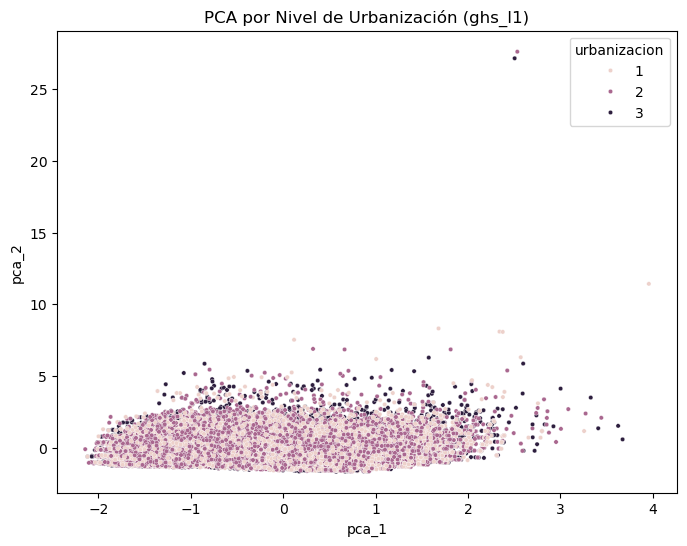

In [19]:
pca_df = pd.DataFrame(pca_result[:, :2], columns=["pca_1", "pca_2"])
pca_df["urbanizacion"] = df["ghs_l1"]
pca_df.head()

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="pca_1", y="pca_2", hue="urbanizacion", s=10)
plt.title("PCA por Nivel de Urbanización (ghs_l1)")
plt.show()

## **9 y 10. Reducción No Lineal: UMAP y t-SNE**
Para la visualización final, necesitamos algoritmos capaces de detectar estructuras complejas (no lineales).
*   **UMAP:** Preserva tanto la estructura local como la global mejor que t-SNE y es más rápido. Será nuestra base principal para graficar los clusters en el siguiente notebook.
*   **Visualización:** Coloreamos por `ghs_l1` (urbanización) para confirmar visualmente si existe una separación natural entre lo urbano y lo rural en el espacio reducido.

## **9. UMAP 2D para visualización (estructura no lineal)**

In [20]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

umap_result = umap_model.fit_transform(X_scaled)

umap_df = pd.DataFrame(umap_result, columns=["umap_1","umap_2"])

## **10. Graficar UMAP coloreado por urbanización (ghs_l1)**

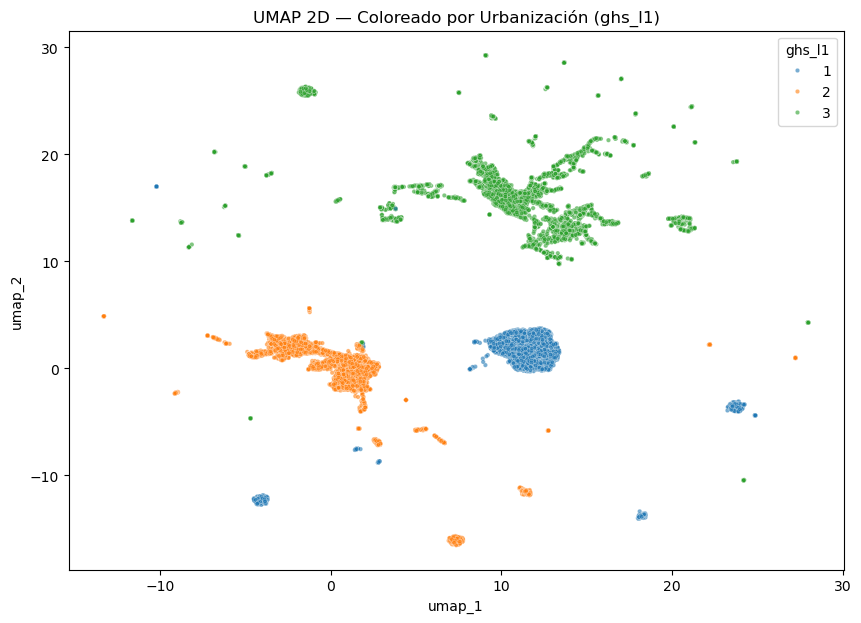

In [22]:
viz = pd.concat([umap_df, X_sample[grupar].reset_index(drop=True)], axis=1)

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=viz,
    x="umap_1", y="umap_2",
    hue=grupar, palette="tab10", s=10, alpha=0.6
)
plt.title("UMAP 2D — Coloreado por Urbanización (ghs_l1)")
plt.show()

In [23]:
umap_model = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
umap_result = umap_model.fit_transform(X_enc)

umap_df = pd.DataFrame(umap_result, columns=["umap_1", "umap_2"])
umap_df["urbanizacion"] = df["ghs_l1"]
umap_df.head()

,umap_1,umap_2,urbanizacion
0,-2.483555,21.471657,3
1,21.675484,-15.174466,3
2,4.874802,-3.024218,3
3,10.784920,11.096844,3
4,9.180115,11.333056,3


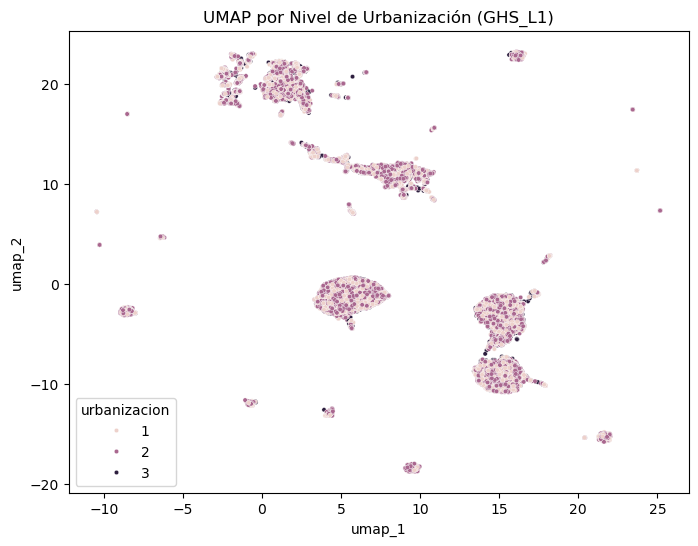

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=umap_df, x="umap_1", y="umap_2", hue="urbanizacion", s=10)
plt.title("UMAP por Nivel de Urbanización (GHS_L1)")
plt.show()

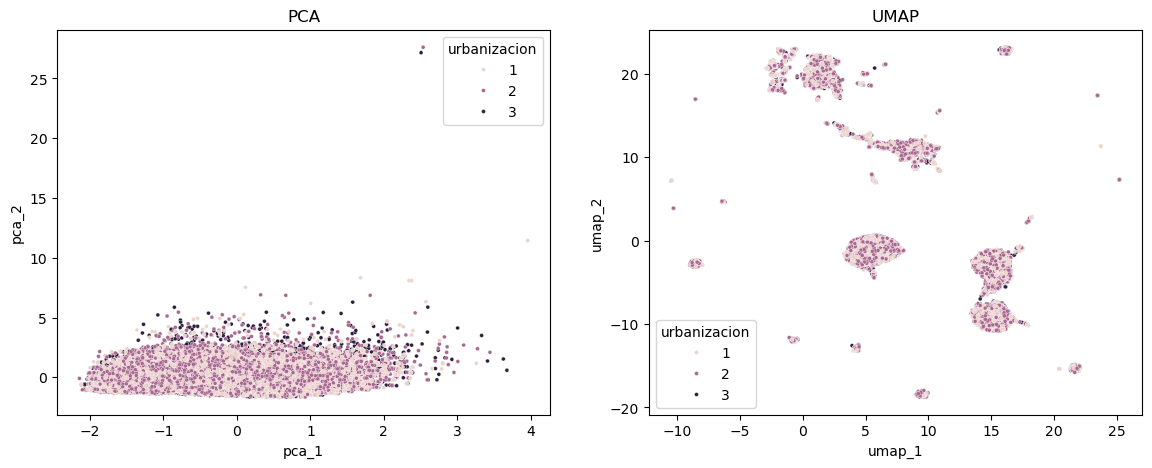

In [25]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.scatterplot(ax=ax[0], data=pca_df, x="pca_1", y="pca_2", hue="urbanizacion", s=8)
ax[0].set_title("PCA")

sns.scatterplot(ax=ax[1], data=umap_df, x="umap_1", y="umap_2", hue="urbanizacion", s=8)
ax[1].set_title("UMAP")

plt.show()

In [26]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42,
)

tsne_result = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(tsne_result, columns=["tsne_1","tsne_2"])
tsne_df.head()

,tsne_1,tsne_2
0,66.366776,70.561203
1,-11.721901,-12.384493
2,-12.513182,-54.312508
3,51.953342,31.471668
4,21.166107,-31.057123


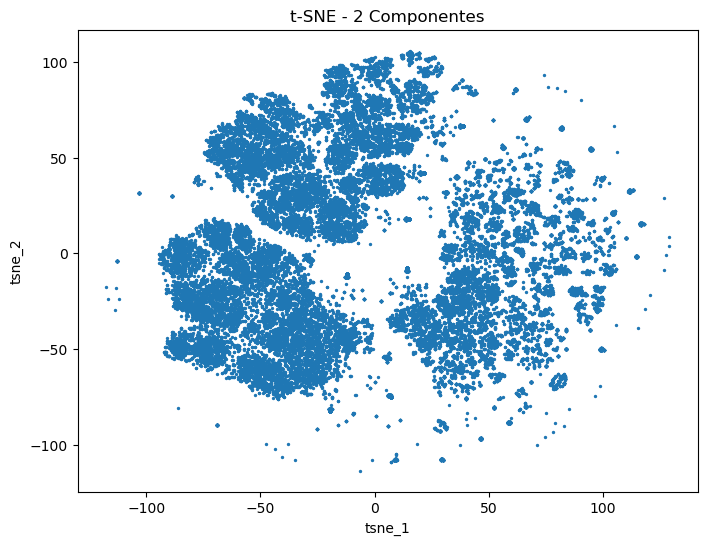

In [27]:
plt.figure(figsize=(8,6))
plt.scatter(tsne_df["tsne_1"], tsne_df["tsne_2"], s=2)
plt.title("t-SNE - 2 Componentes")
plt.xlabel("tsne_1")
plt.ylabel("tsne_2")
plt.show()

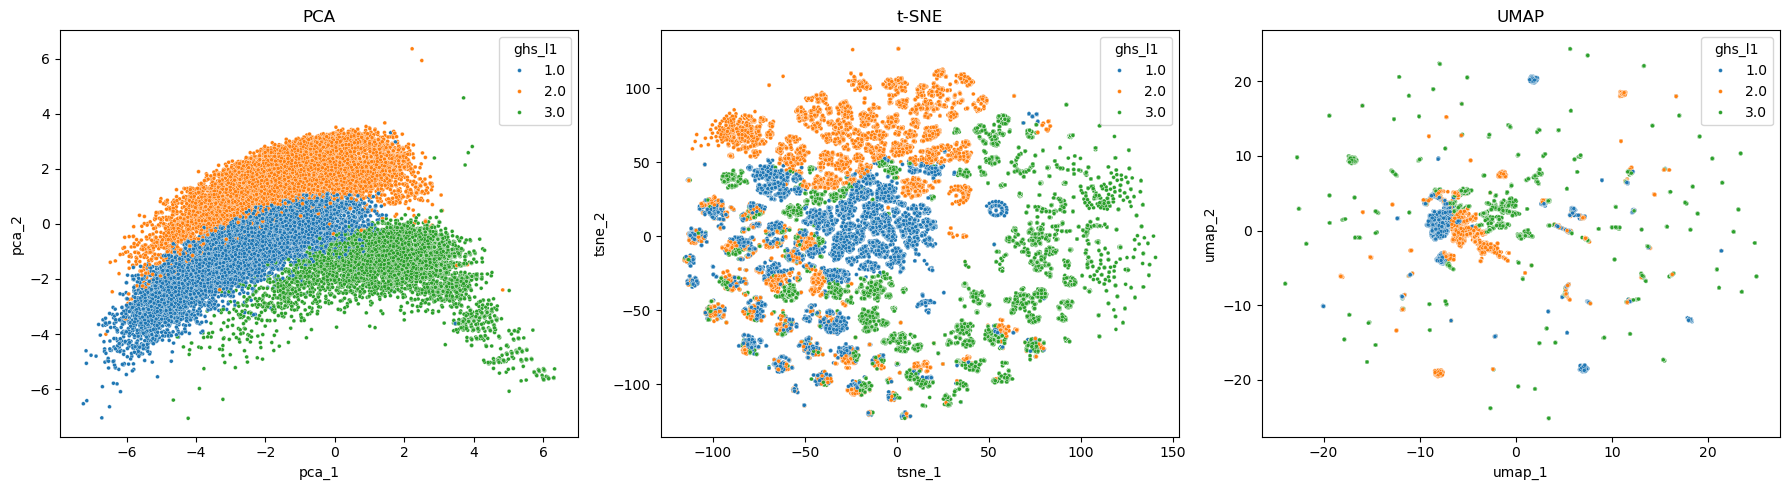

In [28]:
color_var = "ghs_l1"  # la variable para colorear


X_sample_enc = X_enc.copy()
y_color = X_imp[color_var].reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample_enc)

# PCA
pca = PCA(n_components=2, random_state=42)
pca_res = pca.fit_transform(X_scaled)

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)
tsne_res = tsne.fit_transform(X_scaled)

# UMAP
umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    random_state=42
)
umap_res = umap_model.fit_transform(X_scaled)

# Unir resultados en un DataFrame para graficar
plot_df = pd.DataFrame({
    "pca_1": pca_res[:,0], "pca_2": pca_res[:,1],
    "tsne_1": tsne_res[:,0], "tsne_2": tsne_res[:,1],
    "umap_1": umap_res[:,0], "umap_2": umap_res[:,1],
    color_var: y_color.values
})

# Graficar
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.scatterplot(data=plot_df, x="pca_1", y="pca_2", hue=color_var, s=8, palette="tab10")
plt.title("PCA")

plt.subplot(1,3,2)
sns.scatterplot(data=plot_df, x="tsne_1", y="tsne_2", hue=color_var, s=8, palette="tab10")
plt.title("t-SNE")

plt.subplot(1,3,3)
sns.scatterplot(data=plot_df, x="umap_1", y="umap_2", hue=color_var, s=8, palette="tab10")
plt.title("UMAP")

plt.tight_layout()
plt.show()



##  **11. Exportar dataset reducido (para Notebook 03)**

In [33]:
final_df.head()

,pca_1,pca_2,umap_1,umap_2
0,1.341647,-0.638687,-2.483555,21.471657
1,-0.240391,-0.120306,21.675484,-15.174466
2,-0.496116,-0.997139,4.874802,-3.024218
3,1.185772,0.128228,10.784920,11.096844
4,0.023866,0.379015,9.180115,11.333056


In [30]:
final_df = pd.concat([pca_df, umap_df], axis=1)
final_df.to_csv("df_50k_reducido.csv", index=False)
print("Exportado df_50k_reducido.csv")

Exportado df_50k_reducido.csv
